In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
from astropy.io import fits
from astropy.table import Table
from astropy.table import vstack
import os

from scipy import stats
import tensorflow as tf
import tensorflow_datasets as tfds
import keras_tuner as kt
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import pickle

2025-06-12 16:21:22.248071: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1749759692.695378  932500 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749759695.587938  932500 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1749759726.336091  932500 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1749759726.336122  932500 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1749759726.336125  932500 computation_placer.cc:177] computation placer alr

### Import data

In [ ]:
fits_file_2384a = '/home/habjan.e/SuperBIT_code/Redshift_ml/data/Abell2384a_colors_mags.fits'
hdul_2384a = fits.open(fits_file_2384a)
data_2384a = Table(hdul_2384a[1].data)

fits_file_2384b = '/home/habjan.e/SuperBIT_code/Redshift_ml/data/Abell2384b_colors_mags.fits'
hdul_2384b = fits.open(fits_file_2384b)
data_2384b = Table(hdul_2384b[1].data)

fits_file_3667 = '/home/habjan.e/SuperBIT_code/Redshift_ml/data/Abell3667_colors_mags.fits'
hdul_3667 = fits.open(fits_file_3667)
data_3667 = Table(hdul_3667[1].data)

fits_file_3571 = '/home/habjan.e/SuperBIT_code/Redshift_ml/data/Abell3571_colors_mags.fits'
hdul_3571 = fits.open(fits_file_3571)
data_3571 = Table(hdul_3571[1].data)

fits_file_3827 = '/home/habjan.e/SuperBIT_code/Redshift_ml/data/Abell3827_colors_mags.fits'
hdul_3827 = fits.open(fits_file_3827)
data_3827 = Table(hdul_3827[1].data)

fits_file_cosmos113 = '/home/habjan.e/SuperBIT_code/Redshift_ml/data/COSMOS113_colors_mags.fits'
hdul_cosmos113 = fits.open(fits_file_cosmos113)
data_cosmos113 = Table(hdul_cosmos113[1].data)

fits_file_1689 = '/projects/mccleary_group/saha/data/Abell1689/sextractor_dualmode/out/Abell1689_colors_mags.fits'
hdul_1689 = fits.open(fits_file_1689)
data_1689 = Table(hdul_1689[1].data)

data = vstack([data_2384a, data_2384b, data_3667, data_3571, data_3827])

redshift_col = 'Z_lovoccs'
data_z = data[~np.isnan(np.array(data[redshift_col])) & (np.array(data[redshift_col]) > 0)]
x_cols = ['m_b', 'm_g', 'm_u', 'R_b', 'R_g',  'R_u']

cosmos_col = 'Z_desi'
data_cosmos = data_cosmos113[~np.isnan(np.array(data_cosmos113[cosmos_col])) & (np.array(data_cosmos113[cosmos_col]) > 0)]

x = np.array([data_z[x_cols[i]] for i in range(len(x_cols))]).T
y = np.array([data_z[redshift_col]]).T

### Import model

In [ ]:
path = os.getcwd() + '/Tensorflow_models/mlp_redshift.keras'

check_model = tf.keras.models.load_model(path)

### Compare true and predicted redshifts

In [ ]:
model_out = check_model.predict(x)

plot_bool = (model_out > 0 ) & (model_out < 5)

ob_excluded = len(np.where(~plot_bool)[0])

plt.scatter(y, model_out, c='r', label = f'Objects Excluded: {ob_excluded}', s=5)

mod_min = np.min(model_out[plot_bool])
mod_max = np.max(model_out[plot_bool])
line = np.linspace(mod_min - 5, mod_max + 5, 100)
plt.plot(line, line, c='k')

plt.xlim(-0.1, 2)
plt.ylim(-0.1, 2)

plt.title('Training Dataset')
plt.xlabel('BPZ Redshifts', fontsize = 15)
plt.ylabel('MLP Redshifts', fontsize = 15)

plt.legend()

# CNN

### Pick a suffix (this is temporary)

In [ ]:
suffix = '_im'

### Visualize Vignettes

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(16, 4), gridspec_kw={'wspace': 0.1})

obj = 100

upp = 0.99
low = 0.5

fig.suptitle(f'Object {obj}')

# Plot into each subplot
axs[0].imshow(data_z['VIGNET_u' + suffix][obj], vmin=np.nanquantile(data_z['VIGNET_u' + suffix][obj], low), 
vmax=np.nanquantile(data_z['VIGNET_u' + suffix][obj], upp))

axs[1].imshow(data_z['VIGNET_b' + suffix][obj], vmin=np.nanquantile(data_z['VIGNET_b' + suffix][obj], low), 
vmax=np.nanquantile(data_z['VIGNET_b' + suffix][obj], upp))

axs[2].imshow(data_z['VIGNET_g' + suffix][obj], vmin=np.nanquantile(data_z['VIGNET_g' + suffix][obj], low), 
vmax=np.nanquantile(data_z['VIGNET_g' + suffix][obj], upp))

### Import CNN model

In [ ]:
path = os.getcwd() + '/Tensorflow_models/cnn_redshift' + suffix + '.keras'

cnn_model = tf.keras.models.load_model(path)

### CNN test data and predictions

In [ ]:
data_path = os.getcwd().replace('ml_redshifts', 'data') + '/cnn_data/'

trainx_im = np.load(data_path + 'trainx_cnn' + suffix + '.npy')
trainy_im = np.load(data_path + 'trainy_cnn' + suffix + '.npy')
testx_im = np.load(data_path + 'testx_cnn' + suffix + '.npy')
testy_im = np.load(data_path + 'testy_cnn' + suffix + '.npy')

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(16, 4), gridspec_kw={'wspace': 0.1})

obj = 3

upp = 0.99
low = 0.5

fig.suptitle(f'Object {obj}')

# Plot into each subplot
axs[0].imshow(trainx_im[obj, :, :, 0], vmin=np.nanquantile(trainx_im[obj, :, :, 0], low), 
vmax=np.nanquantile(trainx_im[obj, :, :, 0], upp))

axs[1].imshow(trainx_im[obj, :, :, 1], vmin=np.nanquantile(trainx_im[obj, :, :, 1], low), 
vmax=np.nanquantile(trainx_im[obj, :, :, 1], upp))

axs[2].imshow(trainx_im[obj, :, :, 2], vmin=np.nanquantile(trainx_im[obj, :, :, 2], low), 
vmax=np.nanquantile(trainx_im[obj, :, :, 2], upp))

### CNN predictions

In [ ]:
cnn_pred_train = cnn_model.predict(trainx)
cnn_pred_test = cnn_model.predict(testx)

### CNN comparison

In [ ]:
plt.scatter(trainy, cnn_pred_train, s=5, c='b', label='Training Data')
plt.scatter(testy, cnn_pred_test, s=5, c='r', label='Test Data')

one_to_one = np.linspace(0, 2, 100)
plt.plot(one_to_one, one_to_one, c='k')

plt.xlim(0,2)
plt.ylim(0,2)

plt.xlabel('BPZ Redshifts', fontsize = 15)
plt.ylabel('CNN Vignette predictions', fontsize = 15)
plt.title('Raw Vignettes')
plt.legend()

### Make a histogram that shows the difference between true and predicted redshift

In [ ]:
diff_train = trainy - cnn_pred_train
diff_test = testy - cnn_pred_test

bins = np.linspace(-1.5, 1.5, 100)

plt.hist(diff_train, density = True, color='blue', bins=bins, label='Training Data')
plt.hist(diff_test, density = True,color='red', bins=bins, label='Test Data')

plt.axvline(np.median(diff_train), c = 'blue', linestyle = '--', label = f'Median: {np.round(np.median(diff_train), 3)}')
plt.axvline(np.median(diff_test), c = 'red', linestyle = '--', label = f'Median: {np.round(np.median(diff_test), 3)}')

plt.xlabel('True - Predicted', fontsize = 15)
plt.ylabel('Density', fontsize = 15)
plt.title('Raw Vignettes')
plt.legend()

# Jax implementation

In [2]:
import jax

### Import parameters

In [13]:
suffix_jax = ''

save_path = os.getcwd() + '/Jax_models/cnn_model_params' + suffix_jax + '.pkl'

with open(save_path, 'rb') as f:
    loaded_params = pickle.load(f)

### Import model

In [14]:
import sys
sys.path.append(os.getcwd() + '/Jax_models')
from jax_models import CNNModel
from training_structure import JaxTraining
model = CNNModel()

### Import jax data

In [15]:
data_path = os.getcwd().replace('ml_redshifts', 'data') + '/cnn_data/'

trainx = np.load(data_path + 'trainx_cnn_jax.npy')
trainy = np.load(data_path + 'trainy_cnn_jax.npy').T[0, :]
trainy_err = np.load(data_path + 'trainy_err_cnn_jax.npy').T[0, :]

testx = np.load(data_path + 'testx_cnn_jax.npy')
testy = np.load(data_path + 'testy_cnn_jax.npy').T[0, :]
testy_err = np.load(data_path + 'testy_err_cnn_jax.npy').T[0, :]

test_loss = np.load(data_path + 'test_loss.npy')
train_loss = np.load(data_path + 'train_loss.npy')

### Predictions

In [16]:
pred_train = JaxTraining.predict(model = model, params = loaded_params, x = trainx, batch_size=32)
pred_test = JaxTraining.predict(model = model, params = loaded_params, x = testx, batch_size=32)

### Make a scatter plot of the jax classification

Text(0, 0.5, 'GNLL Loss')

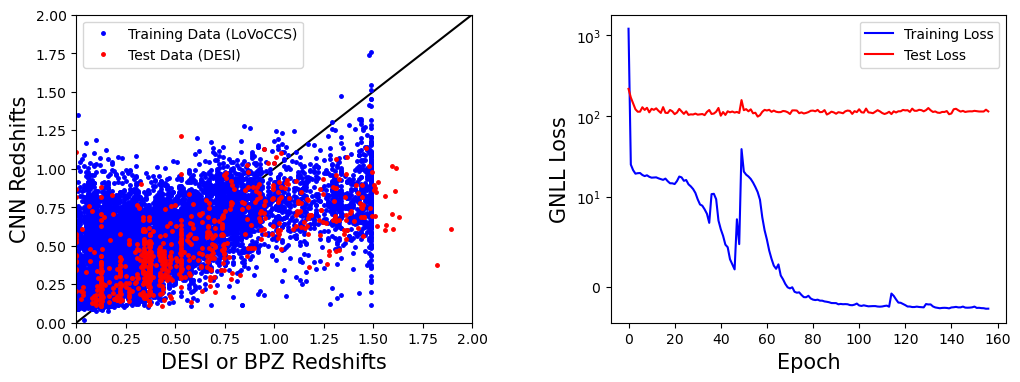

In [17]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={'wspace': 0.35})

# Plot into each subplot
one_to_one = np.linspace(0, 2, 100)
axs[0].plot(one_to_one, one_to_one, c='k')
axs[0].errorbar(trainy, pred_train, c='b', fmt='.', capsize=2, markersize=5, label='Training Data (LoVoCCS)') #xerr = trainy_err,
axs[0].errorbar(testy[:690], pred_test[:690], c='r', fmt='.', capsize=2, markersize=5, label='Test Data (DESI)') #xerr = testy_err,

axs[0].set_xlim(0,2)
axs[0].set_ylim(0,2)

axs[0].set_xlabel('DESI or BPZ Redshifts', fontsize = 15)
axs[0].set_ylabel('CNN Redshifts', fontsize = 15)
axs[0].legend(loc = 'upper left')

epochs = np.arange(0, len(test_loss), 1)
axs[1].plot(epochs, train_loss, c='b', label='Training Loss')
axs[1].plot(epochs, test_loss, c='r', label='Test Loss')

axs[1].set_yscale('symlog', linthresh=10)

axs[1].legend(loc = 'upper right')
axs[1].set_xlabel('Epoch', fontsize = 15)
axs[1].set_ylabel('GNLL Loss', fontsize = 15)

### Plot some data

In [ ]:
for obj in range(20, 40): 

    fig, axs = plt.subplots(1, 3, figsize=(16, 4), gridspec_kw={'wspace': 0.1})

    upp = 0.99
    low = 0.5

    diff = trainy[:train_sams][obj] - preds_train[obj]

    fig.suptitle(f'Object {obj} | Redshift difference: {np.round(diff, 4)}')

    # Plot into each subplot
    axs[0].imshow(trainx[obj, :, :, 0], vmin=np.nanquantile(trainx[obj, :, :, 0], low), 
    vmax=np.nanquantile(trainx[obj, :, :, 0], upp))

    axs[1].imshow(trainx[obj, :, :, 1], vmin=np.nanquantile(trainx[obj, :, :, 1], low), 
    vmax=np.nanquantile(trainx[obj, :, :, 1], upp))

    axs[2].imshow(trainx[obj, :, :, 2], vmin=np.nanquantile(trainx[obj, :, :, 2], low), 
    vmax=np.nanquantile(trainx[obj, :, :, 2], upp))

    plt.show()